In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/ecommerce_encoded.csv")

In [3]:
df.head()

,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,100001,5033,2,1360,2,0.000000,0,0,0,56,1,3,0,0
1,100002,5038,3,4272,2,64.000000,0,0,0,46,0,3,0,0
2,100003,5266,5,3592,2,0.000000,0,0,0,32,1,5,0,0
3,100004,5120,1,966,2,2.666667,0,0,0,25,1,6,0,0
4,100005,5191,1,4926,2,627.500000,2,0,0,38,1,3,0,0


In [4]:
X = df[
[
"Browsing_Time",
"Cart_Addition",
"Previous_Purchases",
"Rating",
"Price",
"Discount_Applied",
"Total_Spending"
]
]

y = df["Purchase_Status"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42,

stratify=y

)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [7]:
joblib.dump(
    scaler,
    "../models/classification_scaler.pkl"
)

['../models/classification_scaler.pkl']

In [8]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
predictions = model.predict(X_test)

In [13]:
probabilities = model.predict_proba(X_test)[:,1]

In [14]:
results = pd.DataFrame({

"Actual":y_test.values,

"Predicted":predictions,

"Probability":probabilities

})

results.head(10)

,Actual,Predicted,Probability
0,0,0,0.000069
1,0,0,0.007935
2,0,0,0.000358
3,0,0,0.000148
4,0,0,0.000006
5,0,0,0.000196
6,0,0,0.000008
7,0,0,0.000048
8,0,0,0.000013
9,0,0,0.001127


In [15]:
accuracy = accuracy_score(

y_test,

predictions

)

print("Accuracy :",accuracy)

Accuracy : 1.0


In [16]:
precision = precision_score(

y_test,

predictions

)

print("Precision :",precision)

Precision : 1.0


In [17]:
recall = recall_score(

y_test,

predictions

)

print("Recall :",recall)

Recall : 1.0


In [18]:
f1 = f1_score(

y_test,

predictions

)

print("F1 Score :",f1)

F1 Score : 1.0


In [19]:
roc = roc_auc_score(

y_test,

probabilities

)

print("ROC AUC :",roc)

ROC AUC : 1.0


In [20]:
print(

classification_report(

y_test,

predictions

)

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2059
           1       1.00      1.00      1.00       382

    accuracy                           1.00      2441
   macro avg       1.00      1.00      1.00      2441
weighted avg       1.00      1.00      1.00      2441



In [21]:
cm = confusion_matrix(

y_test,

predictions

)

cm

array([[2059,    0],
       [   0,  382]])

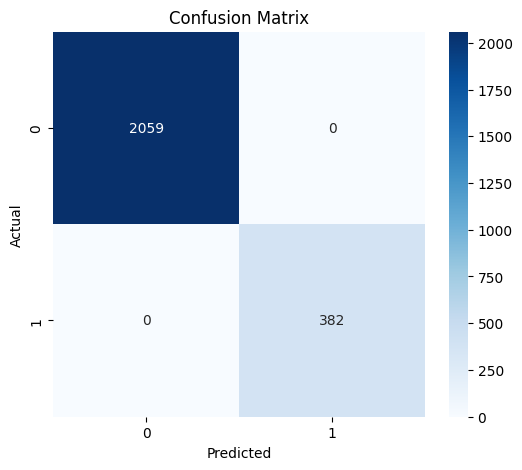

In [22]:
plt.figure(figsize=(6,5))

sns.heatmap(

cm,

annot=True,

fmt="d",

cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [23]:
performance = pd.DataFrame({

"Metric":[

"Accuracy",

"Precision",

"Recall",

"F1 Score",

"ROC AUC"

],

"Value":[

accuracy,

precision,

recall,

f1,

roc

]

})

performance

,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
4,ROC AUC,1.0


In [24]:
performance.to_csv(

"../reports/classification_results.csv",

index=False

)

In [25]:
joblib.dump(

model,

"../models/logistic_regression_model.pkl"

)

['../models/logistic_regression_model.pkl']

In [26]:
loaded_model = joblib.load(

"../models/logistic_regression_model.pkl"

)

print("Model Loaded Successfully")

Model Loaded Successfully


In [27]:
sample = X_test[0].reshape(1,-1)

prediction = loaded_model.predict(sample)

probability = loaded_model.predict_proba(sample)

print("Prediction :",prediction[0])

print("Purchase Probability :",round(probability[0][1]*100,2),"%")

Prediction : 0
Purchase Probability : 0.01 %


In [28]:
results.head(10)

,Actual,Predicted,Probability
0,0,0,0.000069
1,0,0,0.007935
2,0,0,0.000358
3,0,0,0.000148
4,0,0,0.000006
5,0,0,0.000196
6,0,0,0.000008
7,0,0,0.000048
8,0,0,0.000013
9,0,0,0.001127


In [29]:
results.to_csv(

"../reports/purchase_predictions.csv",

index=False

)